In [4]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [2]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)
df = df[df['session'] == 2]

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [76]:
import os
import re

def get_decod(subject, decod_dir, roi='NPC_R', session='ses1-en_ses2-de', E_spec = ''):
    #mask='NPC_R'

    fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
    for f in fils:
        if re.match(f'{subject}_{session}_mask-{roi}.*pars.tsv$', f):
            file = f

    #subject = f'{sub:02d}'
    pdf = op.join(decod_dir,f'{subject}','func', file)
    pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
    if not pdf.index.name == 'trial_nr':
        pdf = pdf.set_index('trial_nr')
    pdf.columns = pdf.columns.astype(float)
    pdf = pdf.loc[:, np.log(5):np.log(28*4)]

    E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)
    E = pd.DataFrame(E)
    E = E.rename(columns={0:f'E{E_spec}'})
    pdf /= np.trapz(pdf, pdf.columns.astype(float))[:, np.newaxis] #normalizing

    E['sd'] = np.trapz(np.abs(E.values - pdf.columns.astype(float).values[np.newaxis, :]) * pdf, pdf.columns, axis=1)
    E['subject'] = int(subject[4:])
    E['roi'] = roi
    E = E.reset_index().set_index(['subject','trial_nr'])
    
    return E


In [71]:
subjects = subFolders[0]
roi = 'NPC1_R'
session = 'ses-2'
decod_dir = decod_dir_within

fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
print(fils)
for f in fils:
    print(re.match(f'{subject}_{session}_mask-{roi}.*pars.tsv$', f))
    if re.match(f'{subject}_{session}_mask-{roi}.*pars.tsv$', f):
        file = f




['._sub-61_ses-2_mask-NPC1_R_space-T1w_pars.tsv', 'sub-61_ses-1_mask-NPC_R_space-T1w_pars.tsv', 'sub-61_ses-1_mask-NPC_R_space-T1w_r2s.tsv', 'sub-61_ses-2_mask-NPC_R_space-T1w_pars.tsv', 'sub-61_ses-2_mask-NPC_R_space-T1w_r2s.tsv', 'sub-61_ses-2_mask-NPC1_R_space-T1w_r2s.tsv', 'sub-61_ses-2_mask-NPC3_R_space-T1w_r2s.tsv', 'sub-61_ses-2_mask-NPC1_R_space-T1w_pars.tsv', 'sub-61_ses-2_mask-NPC3_R_space-T1w_pars.tsv']
None
None
None
None
None
None
None
<re.Match object; span=(0, 43), match='sub-61_ses-2_mask-NPC1_R_space-T1w_pars.tsv'>
None


In [77]:
E_w = get_decod(subject, decod_dir_within, roi=roi, session='ses-2',E_spec='_w')

In [78]:
Es_across = pd.DataFrame()
Es_within = pd.DataFrame()

decod_dir_across = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume.svoxels.ses1-en_ses2-de.denoise.retroicor' )
decod_dir_within = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume.cv_voxel_selection.denoise.retroicor' )

for subject in subFolders:
    for roi in ['NPC_R', 'NPC1_R', 'NPC3_R']:
        try:
            E_a = get_decod(subject, decod_dir_across, roi=roi, session='ses1-en_ses2-de',E_spec='_a') # acorss decoding
            Es_across = pd.concat([Es_across, E_a])

            E_w = get_decod(subject, decod_dir_within, roi=roi, session='ses-2',E_spec='_w') # within
            Es_within = pd.concat([Es_within, E_w])
        except:
            x = 1
            print(f'{subject} makes problems')

sub-01 makes problems
sub-01 makes problems
sub-01 makes problems


In [83]:
Es = Es_within.set_index('roi', append=True).join(Es_across.set_index('roi', append=True), lsuffix='_w', rsuffix='_a')
Es['E_diff'] = Es['E_w'] - Es['E_a']    

In [85]:
df_comb = Es.join(df.reset_index().set_index(['subject','trial_nr'])[['n1', 'group', 'risky_first']])
df_comb['log_n1'] = np.log(df_comb['n1'])
#df_comb.set_index('roi', append=True, inplace=True)
df_comb = df_comb.loc[df_comb.xs('NPC1_R', level='roi').index.unique('subject')] # only include subjects that have all 3 ROIs|
print(df_comb.index.unique('subject'))
df_comb.head()

Int64Index([ 2,  3,  4,  5,  9, 10, 12, 13, 14, 16, 17, 18, 19, 21, 22, 23, 24,
            25, 26, 28, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
            45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 59, 61],
           dtype='int64', name='subject')


E_w      sd_w       E_a      sd_a    E_diff  \
subject trial_nr roi                                                        
2       1        NPC_R   3.630729  0.237235  3.227458  0.480335  0.403270   
                 NPC1_R  3.865913  0.517594  2.395023  0.553585  1.470890   
                 NPC3_R  3.672549  0.519412  2.692841  0.499650  0.979708   
        2        NPC_R   3.215811  0.250970  3.158594  0.693151  0.057217   
                 NPC1_R  3.725103  0.314991  2.290784  0.466798  1.434319   

                           n1  group risky_first    log_n1  
subject trial_nr roi                                        
2       1        NPC_R   10.0    0.0       False  2.302585  
                 NPC1_R  10.0    0.0       False  2.302585  
                 NPC3_R  10.0    0.0       False  2.302585  
        2        NPC_R   14.0    0.0       False  2.639057  
                 NPC1_R  14.0    0.0       False  2.639057

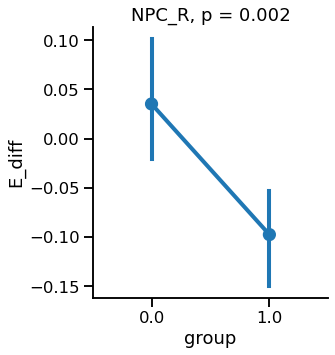

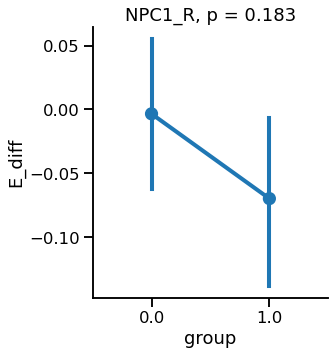

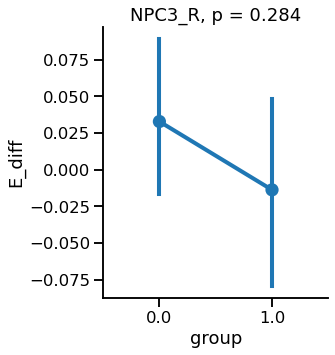

In [87]:
import seaborn as sns
import pingouin
import matplotlib.pyplot as plt

sns.set_context('talk')
var = 'E_diff'
for roi in ['NPC_R','NPC1_R','NPC3_R']:
    temp = df_comb.xs(roi,0,'roi')

    mean_E = temp.groupby(['subject', 'group'])[[var]].mean()
    sns.catplot(data=mean_E.reset_index(), x='group', y=var,kind='point')

    an = pingouin.anova(data=mean_E.reset_index(),dv=var, between='group')
    p_val = an['p-unc'][0].round(3)
    plt.title(f'{roi}, p = {p_val}')


NPC_R 2.0407052667137177e-08
NPC1_R 0.001057262808812292
NPC3_R 0.002996794201901963


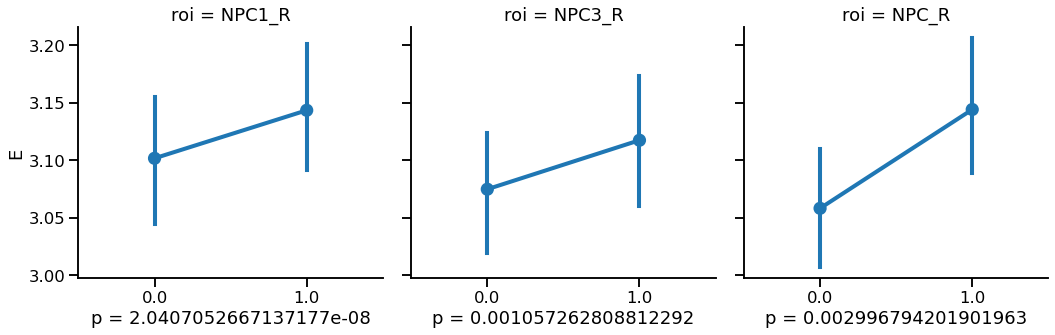

In [40]:
mean_E = df_comb.groupby(['subject', 'group','roi'])[['E']].mean()

g = sns.catplot(data=mean_E.reset_index(), x='group', y='E',kind='point',col='roi')

for i,roi in enumerate(df_comb.index.unique('roi').values):
    temp = df_comb.xs(roi,0,'roi')
    an = pingouin.anova(data=temp.reset_index(),dv='E', between='group')
    p_val = an['p-unc'][0] 
    g.axes[0][i].set_xlabel(f'p = {p_val}')
    print(roi, p_val)